# 

Module 11 – Decision Trees: Hands-on Notebook

This Colab-friendly notebook covers:
- **11.3 – Building a simple decision tree with synthetic data**
- **11.4 – Overfitting and pruning**
- **11.5 – Evaluating a decision tree (accuracy, precision, recall, F1, confusion matrix)**
- **11.6 – ROC curve and AUC**

Each part starts with an explanation in text, then shows simple code and plots.

## Common Imports

In this cell we import the libraries we will use across all parts:
- `pandas` for data handling
- `numpy` for numeric operations
- `matplotlib` for plots
- `sklearn` for machine learning models and metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)

# Make plots a bit larger by default
plt.rcParams['figure.figsize'] = (7, 5)

---
# Module 11.3 – Building a Simple Decision Tree (Synthetic Data)

In this section, we will:
- Create a tiny synthetic dataset with two features
- Train a decision tree classifier
- Visualize the learned tree
- Interpret what the tree is doing

This is only for **intuition**. We keep it very small so students can follow every step.

### 11.3.1 Create a small synthetic dataset

We use a toy example similar to the slides:
- `Weather`: Sunny or Rainy
- `Windy`: 0 (No) or 1 (Yes)
- `Play`: 1 (Play) or 0 (Do not play)

We first create this dataset as a pandas DataFrame.

In [2]:
#Create a small synthetic dataset
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy':   [0,        1,       0,        1,        0,        1,        0,       1],
    'Play':    [1,        0,       1,        1,        0,        0,        1,       0]
}
df_synthetic = pd.DataFrame(data)
df_synthetic

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


### 11.3.2 Encode categorical feature and prepare X, y

Machine learning models in `sklearn` expect numeric inputs.
We will encode:
- `Sunny` → 1
- `Rainy` → 0

`Windy` is already numeric (0/1), so we can use it directly.
The target variable `Play` is already 0/1.

In [3]:
#Encode categorical feature and prepare X, y
df_synthetic['Weather_num'] = df_synthetic['Weather'].map({'Sunny':1, 'Rainy':0})
X_syn = df_synthetic[['Weather_num','Windy']]
y_syn = df_synthetic['Play']
print(X_syn)
print(y_syn)

   Weather_num  Windy
0            1      0
1            0      1
2            1      0
3            1      1
4            0      0
5            0      1
6            1      0
7            0      1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
Name: Play, dtype: int64


### 11.3.3 Train a simple decision tree

We now train a decision tree classifier.

- We set `max_depth=3` just to keep the tree small.
- We fit the model on **all** data (since the goal here is intuition, not evaluation).

In [4]:
#Train a simple decision tree
tree_syn = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_syn.fit(X_syn,y_syn)
tree_syn

DecisionTreeClassifier(max_depth=3, random_state=42)

### 11.3.4 Visualize the tree

Now we plot the tree. This helps students see:
- The root split
- Branches
- Leaf predictions
- How many samples go to each node

Note: `class_names=['No', 'Yes']` aligns with `Play`: 0 = No, 1 = Yes.

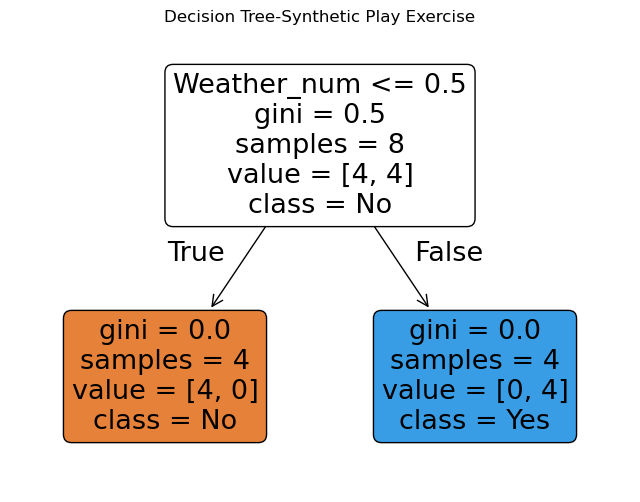

In [5]:
#Visualize the tree
plt.figure(figsize=(8,6))
plot_tree(
    tree_syn,
    feature_names=['Weather_num','Windy'],
    class_names = ['No', 'Yes'],
    filled = True,
    rounded = True,
)
plt.title("Decision Tree-Synthetic Play Exercise")
plt.show()

### 11.3.5 Quick prediction examples

We can now test how the model behaves on a few example cases.
You can ask students to **guess the output** before showing the prediction.

In [6]:
# Example: Sunny (1), not windy (0)
example_1 = pd.DataFrame([[1,0]], columns = ['Weather_num', 'Windy'])
pred_1 = tree_syn.predict(example_1)[0]
print('Sunny, not windy -> Play prediction: ',pred_1)

# Example: Rainy (0), windy (1)
example_2 = pd.DataFrame([[0,1]], columns = ['Weather_num', 'Windy'])
pred_2 = tree_syn.predict(example_2)[0]
print('Rainy, windy -> Play prediction: ',pred_2)

Sunny, not windy -> Play prediction:  1
Rainy, windy -> Play prediction:  0


---
# Module 11.4 – Overfitting and Pruning

In this section, we will:
- See how a **deep tree** can overfit
- Compare it with a **pruned tree** using `max_depth`
- Compare training vs test performance

We will use a slightly larger synthetic dataset so that overfitting becomes visible.

### 11.4.1 Create a slightly larger synthetic dataset

We create a synthetic binary classification dataset using `sklearn.datasets.make_classification`.
This is not a real medical dataset, but it is enough to show overfitting clearly.

In [7]:
#Create a slightly larger synthetic dataset
from sklearn.datasets import make_classification

X_big, y_big = make_classification(
    n_samples=400,#Total data points
    n_features=5,#Total feature number
    n_informative=3,#Total relevant features
    n_redundant=0,#No strong correlation among the features
    n_classes=2,#Target variable/feature class number
    random_state=42,#Every time we will get the similar random dataset
)

X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    X_big, y_big, test_size=0.3, random_state=42
)

X_train_big.shape, X_test_big.shape

((280, 5), (120, 5))

### 11.4.2 Train a deep tree vs a pruned tree

We now train two models:
- `deep_tree`: no depth limit (can easily overfit)
- `pruned_tree`: `max_depth=3`

We compare their **training** and **test** accuracy.

In [8]:
#Train a deep tree vs a pruned tree
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_big, y_train_big)

pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_big, y_train_big)

y_train_pred_deep = deep_tree.predict(X_train_big)
y_test_pred_deep = deep_tree.predict(X_test_big)

y_train_pred_pruned = pruned_tree.predict(X_train_big)
y_test_pred_pruned = pruned_tree.predict(X_test_big)

print('Deep tree – train accuracy:', round(accuracy_score(y_train_big, y_train_pred_deep), 3))
print('Deep tree – test accuracy :', round(accuracy_score(y_test_big, y_test_pred_deep), 3))
print()
print('Pruned tree – train accuracy:', round(accuracy_score(y_train_big, y_train_pred_pruned), 3))
print('Pruned tree – test accuracy :', round(accuracy_score(y_test_big, y_test_pred_pruned), 3))

Deep tree – train accuracy: 1.0
Deep tree – test accuracy : 0.883

Pruned tree – train accuracy: 0.904
Pruned tree – test accuracy : 0.892
